# Chapter 135 — Orthogonality

> **Prerequisites:** ch131 (dot product), ch134 (projections), ch128 (norms)  
> **You will learn:**
> - What orthogonality means and why it is structurally powerful
> - The difference between orthogonal and orthonormal vectors
> - How to build orthonormal sets using the Gram-Schmidt idea
> - Why orthogonal bases make computation cheap and numerically stable
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Two vectors are **orthogonal** if their dot product is zero:
$$\mathbf{u} \perp \mathbf{v} \iff \mathbf{u}\cdot\mathbf{v} = 0$$

In 2D and 3D, orthogonal means perpendicular (90 degrees). In higher dimensions, the dot product is the definition — geometry cannot be visualized but the algebra holds.

A set of vectors is **orthogonal** if every pair is mutually orthogonal. It is **orthonormal** if additionally each vector has unit length:
$$\mathbf{q}_i \cdot \mathbf{q}_j = \delta_{ij} = \begin{cases} 1 & i = j \\ 0 & i \neq j \end{cases}$$

The standard basis $\{\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_n\}$ is orthonormal. Every basis can be orthogonalized.

**Common misconceptions:**
- Orthogonality does not require the vectors to have unit length. Orthonormality adds that requirement.
- The zero vector is orthogonal to every vector (by definition: $\mathbf{0}\cdot\mathbf{v} = 0$), but this is degenerate and uninteresting.
- In statistics, "uncorrelated" features are the statistical analog of orthogonal vectors.

## 2. Intuition & Mental Models

**Geometric:** Orthogonal vectors carry independent directional information. Knowing how far you went east tells you nothing about how far you went north. East and north are orthogonal. This independence is what makes Cartesian coordinates so useful.

**Information-theoretic:** Two orthogonal vectors share no "common component". If you project one onto the other, you get zero. They are maximally informative about independent dimensions.

**Computational:** Expressing a vector in an orthonormal basis is trivial. The coordinate along basis vector $\mathbf{q}_i$ is just $\mathbf{v}\cdot\mathbf{q}_i$ — one dot product per coordinate. In a non-orthogonal basis, finding coordinates requires solving a linear system.

**Numerical stability:** Orthonormal bases are immune to the "ill-conditioning" that plagues general bases. Rotations (which preserve orthonormality) are the most numerically stable linear operations. *(This reappears in ch172 — SVD decomposition.)*

Recall from ch134 that the remainder after projecting $\mathbf{a}$ onto $\mathbf{b}$ is perpendicular to $\mathbf{b}$. That perpendicular remainder is orthogonal to $\mathbf{b}$. Gram-Schmidt uses exactly this idea to build orthogonal sets.

## 3. Visualization

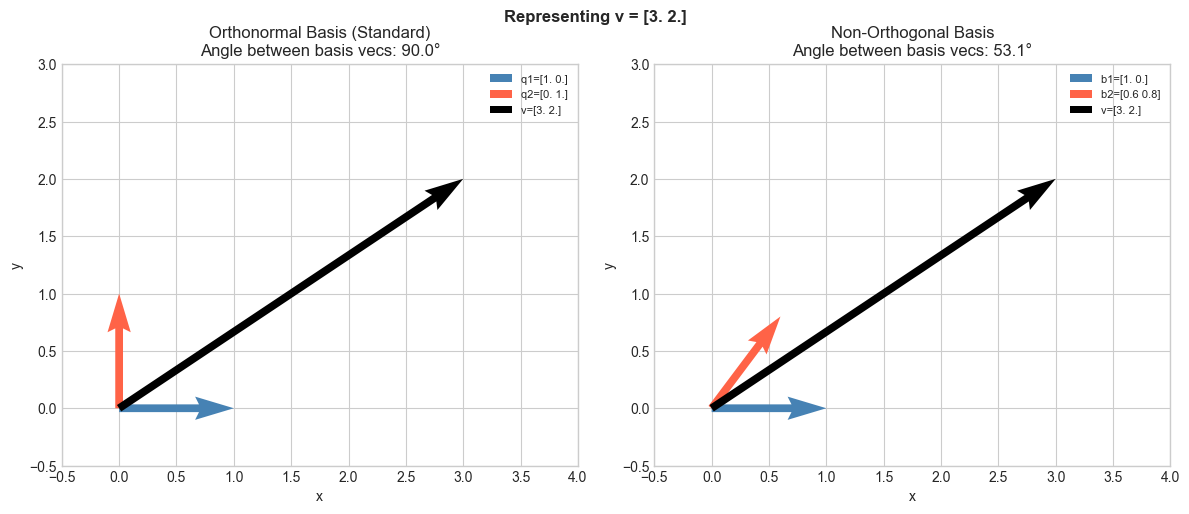

Orthonormal coordinates: c1 = v·q1 = 3.0, c2 = v·q2 = 2.0
Verify: c1*q1 + c2*q2 = [3. 2.]  (should equal v = [3. 2.])


In [1]:
# --- Visualization: Orthogonal vs non-orthogonal bases ---
# Show how representing the same vector in an orthonormal vs skewed basis
# differs in interpretability.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

v = np.array([3.0, 2.0])  # vector to represent

# Orthonormal basis (standard)
q1 = np.array([1.0, 0.0])
q2 = np.array([0.0, 1.0])

# Non-orthogonal basis (skewed)
b1 = np.array([1.0, 0.0])
b2 = np.array([0.6, 0.8])  # not perpendicular to b1

# Coordinates in orthonormal basis: c_i = v · q_i
c1 = np.dot(v, q1)
c2 = np.dot(v, q2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ORIGIN = np.zeros(2)
kw = dict(angles='xy', scale_units='xy', scale=1, width=0.015)

for ax, (u1, u2, label_u1, label_u2, title) in zip(axes, [
    (q1, q2, f'q1={q1}', f'q2={q2}', 'Orthonormal Basis (Standard)'),
    (b1, b2, f'b1={b1}', f'b2={b2}', 'Non-Orthogonal Basis'),
]):
    ax.quiver(*ORIGIN, *u1, color='steelblue', **kw, label=label_u1)
    ax.quiver(*ORIGIN, *u2, color='tomato',    **kw, label=label_u2)
    ax.quiver(*ORIGIN, *v,  color='black',     **kw, label=f'v={v}', linewidth=2)
    dot_angle = np.degrees(np.arccos(np.clip(np.dot(u1, u2) /
                  (np.linalg.norm(u1)*np.linalg.norm(u2)), -1, 1)))
    ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 3)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\nAngle between basis vecs: {dot_angle:.1f}°')
    ax.legend(fontsize=8)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'Representing v = {v}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Orthonormal coordinates: c1 = v·q1 = {c1}, c2 = v·q2 = {c2}")
print(f"Verify: c1*q1 + c2*q2 = {c1*q1 + c2*q2}  (should equal v = {v})")

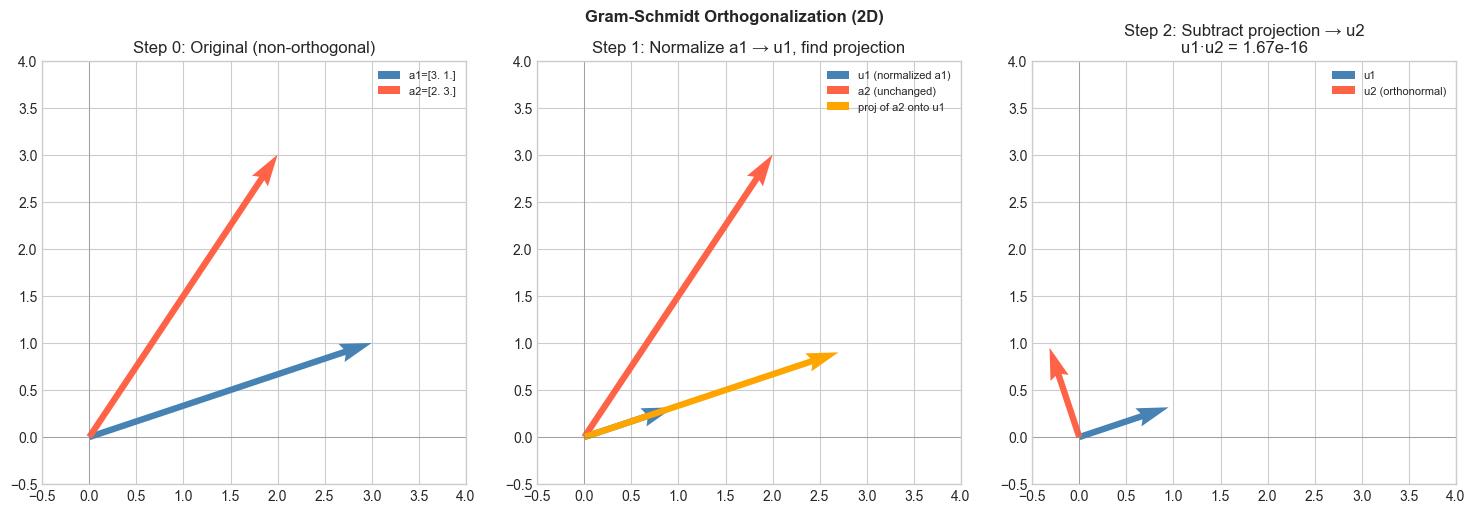

In [2]:
# --- Visualization: Gram-Schmidt step by step in 2D ---
# Start with two linearly independent vectors.
# Step 1: take u1 = a1 (normalized).
# Step 2: remove the u1 component from a2, then normalize.

a1 = np.array([3.0, 1.0])
a2 = np.array([2.0, 3.0])

# Step 1: normalize a1
u1 = a1 / np.linalg.norm(a1)

# Step 2: subtract projection of a2 onto u1, then normalize
proj_a2_onto_u1 = np.dot(a2, u1) * u1
a2_perp = a2 - proj_a2_onto_u1
u2 = a2_perp / np.linalg.norm(a2_perp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original vectors
axes[0].quiver(0,0,a1[0],a1[1], angles='xy', scale_units='xy', scale=1,
                color='steelblue', width=0.015, label=f'a1={a1}')
axes[0].quiver(0,0,a2[0],a2[1], angles='xy', scale_units='xy', scale=1,
                color='tomato', width=0.015, label=f'a2={a2}')
axes[0].set_title('Step 0: Original (non-orthogonal)')

# After step 1
axes[1].quiver(0,0,u1[0],u1[1], angles='xy', scale_units='xy', scale=1,
                color='steelblue', width=0.015, label=f'u1 (normalized a1)')
axes[1].quiver(0,0,a2[0],a2[1], angles='xy', scale_units='xy', scale=1,
                color='tomato', width=0.015, label=f'a2 (unchanged)')
axes[1].quiver(0,0,proj_a2_onto_u1[0],proj_a2_onto_u1[1],
                angles='xy', scale_units='xy', scale=1,
                color='orange', width=0.015, label='proj of a2 onto u1')
axes[1].set_title('Step 1: Normalize a1 → u1, find projection')

# After step 2: orthonormal basis
axes[2].quiver(0,0,u1[0],u1[1], angles='xy', scale_units='xy', scale=1,
                color='steelblue', width=0.015, label='u1')
axes[2].quiver(0,0,u2[0],u2[1], angles='xy', scale_units='xy', scale=1,
                color='tomato', width=0.015, label='u2 (orthonormal)')
axes[2].set_title(f'Step 2: Subtract projection → u2\nu1·u2 = {np.dot(u1,u2):.2e}')

for ax in axes:
    ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)

plt.suptitle('Gram-Schmidt Orthogonalization (2D)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Orthogonality:** $\mathbf{u}\perp\mathbf{v}$ iff $\mathbf{u}\cdot\mathbf{v} = 0$.

**Orthonormal set:** $\{\mathbf{q}_1,\ldots,\mathbf{q}_k\}$ with $\mathbf{q}_i\cdot\mathbf{q}_j = \delta_{ij}$.

**Pythagorean theorem** (orthogonal vectors):
$$\mathbf{u}\perp\mathbf{v} \implies \|\mathbf{u}+\mathbf{v}\|^2 = \|\mathbf{u}\|^2 + \|\mathbf{v}\|^2$$

**Expansion in orthonormal basis:** If $\{\mathbf{q}_1,\ldots,\mathbf{q}_n\}$ is an orthonormal basis for $\mathbb{R}^n$, then for any $\mathbf{v}$:
$$\mathbf{v} = \sum_{i=1}^n (\mathbf{v}\cdot\mathbf{q}_i)\mathbf{q}_i$$

The coefficient $(\mathbf{v}\cdot\mathbf{q}_i)$ is computed with a single dot product — no system to solve.

**Gram-Schmidt algorithm** (classical form):

Given linearly independent vectors $\{\mathbf{a}_1,\ldots,\mathbf{a}_k\}$:
1. $\mathbf{u}_1 = \mathbf{a}_1 / \|\mathbf{a}_1\|$
2. For $j = 2, \ldots, k$:
   - $\tilde{\mathbf{u}}_j = \mathbf{a}_j - \sum_{i=1}^{j-1}(\mathbf{a}_j\cdot\mathbf{u}_i)\mathbf{u}_i$ (remove all prior-direction components)
   - $\mathbf{u}_j = \tilde{\mathbf{u}}_j / \|\tilde{\mathbf{u}}_j\|$

## 5. Python Implementation

In [3]:
# --- Implementation: is_orthogonal, is_orthonormal, gram_schmidt ---

def are_orthogonal(vectors, tol=1e-10):
    """
    Check if all pairs of vectors in a list are mutually orthogonal.

    Args:
        vectors: list of arrays, each shape (n,)
        tol:     tolerance for zero dot product

    Returns:
        bool
    """
    for i in range(len(vectors)):
        for j in range(i+1, len(vectors)):
            if abs(np.dot(vectors[i], vectors[j])) > tol:
                return False
    return True


def are_orthonormal(vectors, tol=1e-10):
    """
    Check if vectors form an orthonormal set.
    """
    if not are_orthogonal(vectors, tol):
        return False
    return all(abs(np.linalg.norm(v) - 1.0) < tol for v in vectors)


def gram_schmidt(vectors):
    """
    Gram-Schmidt orthonormalization.

    Args:
        vectors: list of k linearly independent arrays, each shape (n,)

    Returns:
        Q: list of k orthonormal arrays, each shape (n,)

    Raises:
        ValueError: if a vector becomes zero (linearly dependent input)
    """
    Q = []
    for a in vectors:
        a = np.asarray(a, float).copy()
        # Remove all components along already-found orthonormal directions
        for q in Q:
            a -= np.dot(a, q) * q
        norm = np.linalg.norm(a)
        if norm < 1e-12:
            raise ValueError("Linearly dependent input — Gram-Schmidt failed.")
        Q.append(a / norm)
    return Q


# Test on 3 non-orthogonal vectors in R^3
vecs = [
    np.array([1.0, 1.0, 0.0]),
    np.array([1.0, 0.0, 1.0]),
    np.array([0.0, 1.0, 1.0]),
]

print("Before Gram-Schmidt:")
print(f"  Orthogonal:    {are_orthogonal(vecs)}")
print(f"  Orthonormal:   {are_orthonormal(vecs)}")

Q = gram_schmidt(vecs)

print("\nAfter Gram-Schmidt:")
print(f"  Orthogonal:    {are_orthogonal(Q)}")
print(f"  Orthonormal:   {are_orthonormal(Q)}")

print("\nOrthonormal vectors:")
for i, q in enumerate(Q):
    print(f"  q{i+1} = {np.round(q, 4)},  ||q{i+1}|| = {np.linalg.norm(q):.6f}")

# Validate against numpy QR
A = np.column_stack(vecs)
Q_np, R_np = np.linalg.qr(A)
print("\nFirst column of numpy QR (should match q1 up to sign):")
print(f"  Our q1: {np.round(Q[0], 4)}")
print(f"  QR q1:  {np.round(np.abs(Q_np[:,0]), 4)}")

Before Gram-Schmidt:
  Orthogonal:    False
  Orthonormal:   False

After Gram-Schmidt:
  Orthogonal:    True
  Orthonormal:   True

Orthonormal vectors:
  q1 = [0.7071 0.7071 0.    ],  ||q1|| = 1.000000
  q2 = [ 0.4082 -0.4082  0.8165],  ||q2|| = 1.000000
  q3 = [-0.5774  0.5774  0.5774],  ||q3|| = 1.000000

First column of numpy QR (should match q1 up to sign):
  Our q1: [0.7071 0.7071 0.    ]
  QR q1:  [0.7071 0.7071 0.    ]


In [4]:
# --- Orthonormal basis expansion ---
# Express a vector in an orthonormal basis using only dot products.

np.random.seed(3)
n = 5

# Build an orthonormal basis for R^5 via Gram-Schmidt
raw_basis = [np.random.randn(n) for _ in range(n)]
ON_basis = gram_schmidt(raw_basis)

# Target vector
v = np.random.randn(n)

# Coordinates in orthonormal basis = dot products
coords = np.array([np.dot(v, q) for q in ON_basis])

# Reconstruct
v_reconstructed = sum(c * q for c, q in zip(coords, ON_basis))

print("Original v:", np.round(v, 4))
print("Coords in ON basis:", np.round(coords, 4))
print("Reconstructed v:", np.round(v_reconstructed, 4))
print(f"Max reconstruction error: {np.max(np.abs(v - v_reconstructed)):.2e}")

Original v: [-0.713   0.6252 -0.1605 -0.7688 -0.23  ]
Coords in ON basis: [ 0.1816  0.568   0.5747 -0.9272 -0.1532]
Reconstructed v: [-0.713   0.6252 -0.1605 -0.7688 -0.23  ]
Max reconstruction error: 3.33e-16


## 6. Experiments

In [5]:
# --- Experiment 1: Pythagorean theorem in n dimensions ---
# Hypothesis: for orthogonal vectors, ||u + v||^2 = ||u||^2 + ||v||^2.
# Try changing: N_DIM

N_DIM = 10  # <-- modify this
np.random.seed(1)

u = np.random.randn(N_DIM)
# Make v orthogonal to u via Gram-Schmidt
v_raw = np.random.randn(N_DIM)
v = v_raw - np.dot(v_raw, u)/np.dot(u,u) * u

assert abs(np.dot(u, v)) < 1e-10

lhs = np.linalg.norm(u + v)**2
rhs = np.linalg.norm(u)**2 + np.linalg.norm(v)**2

print(f"||u + v||²         = {lhs:.6f}")
print(f"||u||² + ||v||²    = {rhs:.6f}")
print(f"Equal (Pythagoras): {np.isclose(lhs, rhs)}")

||u + v||²         = 20.102637
||u||² + ||v||²    = 20.102637
Equal (Pythagoras): True


In [6]:
# --- Experiment 2: Gram-Schmidt numerical stability ---
# Classical GS loses orthogonality for nearly-linearly-dependent inputs.
# Try changing: EPSILON (smaller = more nearly dependent vectors)

EPSILON = 1e-6  # <-- modify this (try 1e-1, 1e-6, 1e-12)

# Nearly parallel vectors
a1 = np.array([1.0, 0.0, 0.0])
a2 = np.array([1.0, EPSILON, 0.0])
a3 = np.array([1.0, 0.0, EPSILON])

Q = gram_schmidt([a1, a2, a3])

# Check orthogonality quality
print(f"EPSILON = {EPSILON}")
print(f"q1·q2 = {np.dot(Q[0], Q[1]):.2e}  (should be 0)")
print(f"q1·q3 = {np.dot(Q[0], Q[2]):.2e}  (should be 0)")
print(f"q2·q3 = {np.dot(Q[1], Q[2]):.2e}  (should be 0)")
print("\nAs EPSILON → 0, the vectors become nearly dependent")
print("and numerical errors in Gram-Schmidt grow.")

EPSILON = 1e-06
q1·q2 = 0.00e+00  (should be 0)
q1·q3 = 0.00e+00  (should be 0)
q2·q3 = 0.00e+00  (should be 0)

As EPSILON → 0, the vectors become nearly dependent
and numerical errors in Gram-Schmidt grow.


## 7. Exercises

**Easy 1.** Are $[1, 2, -1]$ and $[3, 0, 3]$ orthogonal? Verify via dot product. *(Expected: yes)*

**Easy 2.** Normalize $[3, 0, 4]$ to unit length. Then verify it is orthogonal to $[0, 1, 0]$. *(Expected: $[0.6, 0, 0.8]$)*

**Medium 1.** Apply `gram_schmidt` to the three vectors $[1,1,0]$, $[1,0,1]$, $[0,1,1]$. Verify the output is orthonormal and spans the same space as the inputs. *(Hint: show that each original vector can be expressed as a linear combination of the output)*

**Medium 2.** Given an orthonormal basis $\{\mathbf{q}_1, \ldots, \mathbf{q}_n\}$ and a target vector $\mathbf{v}$, compute the coordinates and reconstruct $\mathbf{v}$. Then try removing one basis vector from the sum — what is the geometric meaning of the truncated reconstruction? *(Hint: it is the projection onto the subspace spanned by the remaining vectors)*

**Hard.** Implement the **modified Gram-Schmidt** algorithm, which orthogonalizes against the most recently updated vectors (not the original inputs). Show that it is numerically more stable than classical Gram-Schmidt for nearly-dependent vectors by comparing the orthogonality error `|q_i · q_j|` for EPSILON = 1e-8.

## 8. Mini Project — Orthogonal Feature Space

In [ ]:
# --- Mini Project: Orthogonalize Correlated Features ---
# Problem: Machine learning often works better with uncorrelated (orthogonal) features.
#          Use Gram-Schmidt to decorrelate a feature matrix.
# Dataset: 2D dataset with highly correlated features.
# Task: Orthogonalize the feature columns and visualize the result.

np.random.seed(42)
N = 200

# Correlated 2D features
t = np.random.randn(N)
X = np.column_stack([
    t + 0.2 * np.random.randn(N),       # feature 1: nearly = t
    0.8 * t + 0.3 * np.random.randn(N), # feature 2: highly correlated with f1
])

def orthogonalize_features(X):
    """
    Orthogonalize columns of X using Gram-Schmidt.

    Args:
        X: array (n, d) — n samples, d features

    Returns:
        X_orth: array (n, d) — orthogonalized features
    """
    columns = [X[:, j] for j in range(X.shape[1])]
    # TODO: apply gram_schmidt to the list of column vectors
    # TODO: return as stacked array
    pass


# --- Visualize (uncomment after implementing) ---
# X_orth = orthogonalize_features(X)
#
# Before: correlation
# corr_before = np.corrcoef(X.T)[0, 1]
# corr_after  = np.corrcoef(X_orth.T)[0, 1]
#
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# axes[0].scatter(X[:, 0], X[:, 1], alpha=0.5, color='steelblue', s=15)
# axes[0].set_title(f'Original Features\nCorrelation = {corr_before:.3f}')
# axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
#
# axes[1].scatter(X_orth[:, 0], X_orth[:, 1], alpha=0.5, color='tomato', s=15)
# axes[1].set_title(f'Orthogonalized Features\nCorrelation = {corr_after:.3f}')
# axes[1].set_xlabel('Feature 1 (orth)'); axes[1].set_ylabel('Feature 2 (orth)')
# plt.tight_layout()
# plt.show()

# --- Reflection ---
# After orthogonalization, does feature 2 still carry useful information?
# What information does it now capture that feature 1 does not?

## 9. Chapter Summary & Connections

- Two vectors are orthogonal iff $\mathbf{u}\cdot\mathbf{v} = 0$. A set is orthonormal if all pairs are orthogonal and each has unit length.
- In an orthonormal basis, coordinates are dot products: $c_i = \mathbf{v}\cdot\mathbf{q}_i$ — cheap and exact.
- Gram-Schmidt converts any linearly independent set into an orthonormal one by iteratively subtracting projections.
- Orthogonal vectors satisfy the Pythagorean theorem: $\|\mathbf{u}+\mathbf{v}\|^2 = \|\mathbf{u}\|^2 + \|\mathbf{v}\|^2$.

**Forward connections:**
- This reappears in **ch136 — Cross Product**, where the cross product of two vectors is orthogonal to both.
- This reappears in **ch172 — Singular Value Decomposition**, which decomposes any matrix into orthonormal bases for its input and output spaces.
- This reappears in **ch182 — PCA Intuition**, where principal components are orthogonal directions.
- Gram-Schmidt is the foundation of **QR decomposition**, used in ch171.

**Backward connection:**
- This formalizes the perpendicular remainder from **ch134 — Projections**: $\mathbf{e} = \mathbf{a} - \text{proj}_{\mathbf{b}}\mathbf{a}$ is orthogonal to $\mathbf{b}$ by construction.

**Going deeper:** The theory of Hilbert spaces generalizes orthonormality to infinite-dimensional function spaces. Fourier series are orthonormal expansions of functions — exactly the same idea applied to signals.